In [7]:
import pyvista as pv
import numpy as np
import subprocess
import time
import pandas as pd

In [5]:
start_time = time.perf_counter()
result = subprocess.run(
    ['/workspaces/nm/build/pde/example/mf/lin/e_pde_mf_lin'],
    cwd='.',
    capture_output=True,
    text=True,
    check=True,
    # env={
    #   "OMP_NUM_THREADS": "2"
    # }
    )
end_time = time.perf_counter()

print(result.stdout)
print(result.stderr)
print(f"Execution time: {end_time - start_time:.4f} seconds")

[umsh][tel] zone: 18
[umsh][tel] vtx: 1539
[umsh][tel] qud: 1456
[umsh][tel] seg: 164
[fem][std][lin][c2d][asm] ok
[vec][iss][gmr][pet] itr: 48, err: 1.5395415e-10
[fem][sys][slv] ok


Execution time: 0.3306 seconds


In [8]:
df = pd.read_csv('out/control-points.csv')
pd.options.display.max_columns = len(df.columns)

print(df.to_markdown(floatfmt='.3e', tablefmt='github'))

|    |         x |         y |         Az |         Bx |        By |        Bm |
|----|-----------|-----------|------------|------------|-----------|-----------|
|  0 | 2.520e-02 | 1.600e-03 |  9.855e-03 |  1.886e-01 | 9.254e-01 | 9.445e-01 |
|  1 | 3.350e-02 | 2.700e-03 |  1.714e-03 | -4.177e-01 | 1.006e+00 | 1.089e+00 |
|  2 | 3.500e-02 | 9.000e-04 |  1.154e-03 | -5.273e-01 | 8.743e-01 | 1.021e+00 |
|  3 | 3.650e-02 | 2.700e-03 | -1.303e-03 | -6.369e-01 | 1.006e+00 | 1.191e+00 |
|  4 | 4.290e-02 | 3.500e-03 | -8.624e-03 | -1.104e+00 | 1.064e+00 | 1.534e+00 |


2026-03-17 09:35:21.609 (1838.313s) [    7F13C8B58740]vtkXOpenGLRenderWindow.:1458  WARN| bad X server connection. DISPLAY=


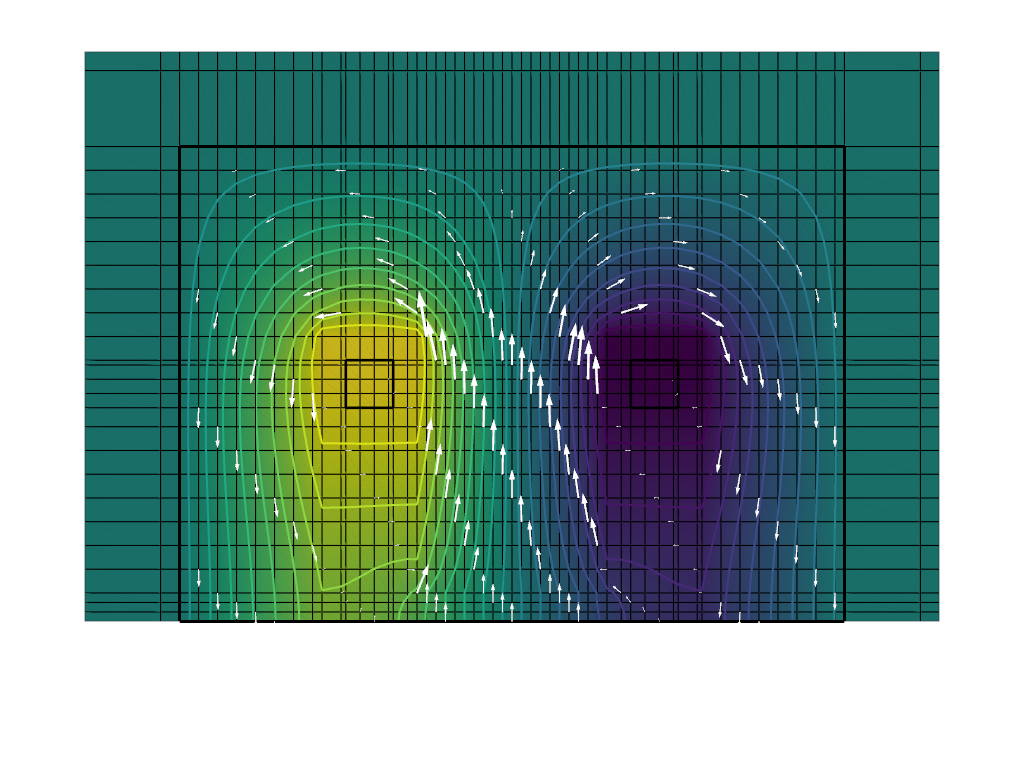

In [9]:
grid_az = pv.CGNSReader('out/emf-0.cgns').read().combine()
grid_bx = pv.CGNSReader('out/emf-1.cgns').read().combine()
grid_by = pv.CGNSReader('out/emf-2.cgns').read().combine()
grid_bm = pv.CGNSReader('out/emf-3.cgns').read().combine()

bx = grid_bx['Bx']
by = grid_by['By']
bm = grid_bm['Bm']

isolines = grid_az.contour(isosurfaces=20, scalars='Az')

ids = np.arange(0, grid_az.n_points, 7)
arrow_src = pv.PolyData(grid_az.points[ids])
arrow_src['B'] = np.c_[bx, by, np.zeros_like(bx)][ids]
arrow_src['Bm'] = bm[ids]

arrows = arrow_src.glyph(
    orient='B',
    scale='Bm',
    factor=0.002
)

plotter = pv.Plotter()

plotter.add_mesh(
    grid_az,
    scalars='Az',
    show_edges=True,
    cmap='viridis',
    show_scalar_bar=False,
)

plotter.add_mesh(
    isolines,
    scalars='Az',
    line_width=2,
    cmap='viridis',
    show_scalar_bar=False
)

plotter.add_mesh(
    arrows,
    color='white',
    lighting=False
)

plotter.add_mesh(
    pv.Rectangle([[0.07, 0, 0], [0.07, 0.05, 0], [0, 0.05, 0]]),
    line_width=3,
    color='black',
    style='wireframe'
)

plotter.add_mesh(
    pv.Rectangle([[0.0225, 0.0225, 0], [0.0225, 0.0275, 0], [0.0175, 0.0275, 0]]),
    line_width=3,
    color='black',
    style='wireframe'
)

plotter.add_mesh(
    pv.Rectangle([[0.0525, 0.0225, 0], [0.0525, 0.0275, 0], [0.0475, 0.0275, 0]]),
    line_width=3,
    color='black',
    style='wireframe'
)

plotter.camera_position = 'xy'
plotter.reset_camera(bounds=[0.005, 0.065, 0.0, 0.05, 0, 0])
plotter.screenshot('result.png', transparent_background=True)
plotter.show(jupyter_backend='static')